# Regression Models in Machine Learning

## The Datasets

### Dataset Description

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(RANDOM_SEED)

# ── Fetch Bike Sharing dataset from UCI ───────────────────────────────────
url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases"
    "/00275/Bike-Sharing-Dataset.zip"
)
import urllib.request, zipfile, io

response = urllib.request.urlopen(url)
zf = zipfile.ZipFile(io.BytesIO(response.read()))
df_raw = pd.read_csv(zf.open("hour.csv"))

print(f"Shape           : {df_raw.shape}")
print(f"Columns         : {list(df_raw.columns)}")
print(f"\nTarget summary  :")
print(df_raw["cnt"].describe().round(1))

Shape           : (17379, 17)
Columns         : ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

Target summary  :
count    17379.0
mean       189.5
std        181.4
min          1.0
25%         40.0
50%        142.0
75%        281.0
max        977.0
Name: cnt, dtype: float64


### Feature Engineering and Selection

In [2]:
# ── Drop non-predictive columns ───────────────────────────────────────────
# 'instant'    : row index
# 'dteday'     : date string (captured by yr, mnth, hr, weekday, etc.)
# 'casual'     : sub-component of cnt — leakage if used as a feature
# 'registered' : sub-component of cnt — leakage if used as a feature

df = df_raw.drop(columns=["instant", "dteday", "casual", "registered"])

# ── Feature matrix and response ───────────────────────────────────────────
X = df.drop("cnt", axis=1)
y = df["cnt"].astype(float)

feature_info = pd.DataFrame({
    "Feature":     X.columns.tolist(),
    "Description": [
        "Season (1=spring, 2=summer, 3=fall, 4=winter)",
        "Year (0=2011, 1=2012)",
        "Month (1–12)",
        "Hour of day (0–23)",
        "Holiday indicator (1=holiday)",
        "Day of week (0=Sunday, …, 6=Saturday)",
        "Working day indicator",
        "Weather situation (1=clear, 2=mist, 3=light rain, 4=heavy rain)",
        "Normalised temperature (0–1)",
        "Normalised apparent temperature (0–1)",
        "Normalised humidity (0–1)",
        "Normalised wind speed (0–1)",
    ],
    "Type": [
        "Categorical", "Binary", "Categorical", "Categorical",
        "Binary", "Categorical", "Binary", "Categorical",
        "Continuous", "Continuous", "Continuous", "Continuous",
    ]
})
print(feature_info.to_string(index=False))
print(f"\nNo missing values: {X.isna().sum().sum() == 0}")

   Feature                                                     Description        Type
    season                   Season (1=spring, 2=summer, 3=fall, 4=winter) Categorical
        yr                                           Year (0=2011, 1=2012)      Binary
      mnth                                                    Month (1–12) Categorical
        hr                                              Hour of day (0–23) Categorical
   holiday                                   Holiday indicator (1=holiday)      Binary
   weekday                           Day of week (0=Sunday, …, 6=Saturday) Categorical
workingday                                           Working day indicator      Binary
weathersit Weather situation (1=clear, 2=mist, 3=light rain, 4=heavy rain) Categorical
      temp                                    Normalised temperature (0–1)  Continuous
     atemp                           Normalised apparent temperature (0–1)  Continuous
       hum                                 

### Data Splitting

In [3]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score

# ── Temporal integrity: split chronologically, not randomly ───────────────
# The original dataset is ordered by date. A random split would allow
# future observations to inform the model, creating subtle leakage.
# We preserve temporal order: first 80% for training, last 20% for test.

split_idx = int(len(X) * 0.80)
X_tr, X_te = X.iloc[:split_idx], X.iloc[split_idx:]
y_tr, y_te = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set   : {X_tr.shape[0]:,} rows  "
      f"(hours {0} – {split_idx - 1})")
print(f"Test set       : {X_te.shape[0]:,} rows  "
      f"(hours {split_idx} – {len(X) - 1})")
print(f"\nTraining target: mean={y_tr.mean():.1f}, std={y_tr.std():.1f}")
print(f"Test target    : mean={y_te.mean():.1f}, std={y_te.std():.1f}")

# ── 10-fold CV object (non-shuffled to respect temporal order) ────────────
kf = KFold(n_splits=10, shuffle=False)

Training set   : 13,903 rows  (hours 0 – 13902)
Test set       : 3,476 rows  (hours 13903 – 17378)

Training target: mean=174.6, std=167.0
Test target    : mean=248.8, std=220.5


### Exploratory Visualisation

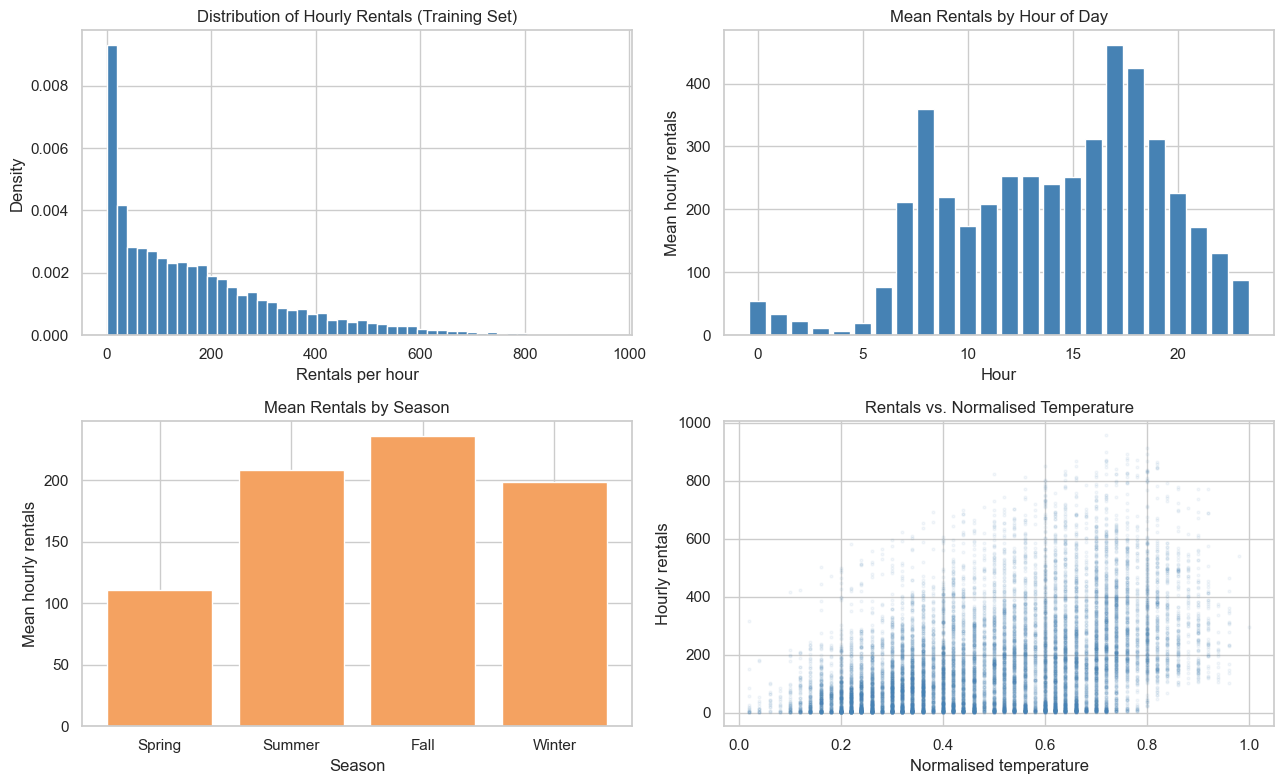

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Panel 1: target distribution
axes[0, 0].hist(y_tr, bins=50, color="steelblue",
                edgecolor="white", density=True)
axes[0, 0].set_title("Distribution of Hourly Rentals (Training Set)")
axes[0, 0].set_xlabel("Rentals per hour")
axes[0, 0].set_ylabel("Density")

# Panel 2: mean rentals by hour of day
hr_mean = df.groupby("hr")["cnt"].mean()
axes[0, 1].bar(hr_mean.index, hr_mean.values,
               color="steelblue", edgecolor="white")
axes[0, 1].set_title("Mean Rentals by Hour of Day")
axes[0, 1].set_xlabel("Hour")
axes[0, 1].set_ylabel("Mean hourly rentals")

# Panel 3: mean rentals by season
season_mean = df.groupby("season")["cnt"].mean()
axes[1, 0].bar(
    ["Spring", "Summer", "Fall", "Winter"],
    season_mean.values, color="#F4A261", edgecolor="white"
)
axes[1, 0].set_title("Mean Rentals by Season")
axes[1, 0].set_xlabel("Season")
axes[1, 0].set_ylabel("Mean hourly rentals")

# Panel 4: rentals vs. temperature
axes[1, 1].scatter(X_tr["temp"], y_tr, alpha=0.06,
                   s=4, color="steelblue")
axes[1, 1].set_title("Rentals vs. Normalised Temperature")
axes[1, 1].set_xlabel("Normalised temperature")
axes[1, 1].set_ylabel("Hourly rentals")

plt.tight_layout()
plt.savefig(FIGURES / "ch12_eda.png", dpi=150, bbox_inches="tight")
plt.show()

## Regression Performance Metrics

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

def regression_report(y_true, y_pred, label=""):
    """Print RMSE, MAE, and R² for a set of predictions."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label:30s}  RMSE={rmse:7.2f}  MAE={mae:7.2f}  R²={r2:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}

def evaluate_regressor(pipe, X_train, y_train, X_test, y_test,
                       cv, model_name="Model"):
    """
    Cross-validate a pipeline on the training set and evaluate on test set.
    Returns a summary dict for inclusion in the final comparison table.
    """
    cv_rmse = -cross_val_score(
        pipe, X_train, y_train, cv=cv,
        scoring="neg_root_mean_squared_error"
    )
    cv_r2 = cross_val_score(
        pipe, X_train, y_train, cv=cv, scoring="r2"
    )
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    return {
        "model":        model_name,
        "cv_rmse_mean": cv_rmse.mean(),
        "cv_rmse_std":  cv_rmse.std(),
        "cv_r2_mean":   cv_r2.mean(),
        "test_rmse":    np.sqrt(mean_squared_error(y_test, y_pred)),
        "test_mae":     mean_absolute_error(y_test, y_pred),
        "test_r2":      r2_score(y_test, y_pred),
    }

# ── Baseline: predict the training mean for every observation ─────────────
y_baseline = np.full(len(y_te), y_tr.mean())
regression_report(y_te, y_baseline, label="Baseline (mean predictor)")

Baseline (mean predictor)       RMSE= 232.61  MAE= 174.98  R²=-0.1130


{'rmse': np.float64(232.60837481037086),
 'mae': 174.98460136882977,
 'r2': -0.11299526466191145}

## Tree-Based Regression

### Controlling Tree Depth

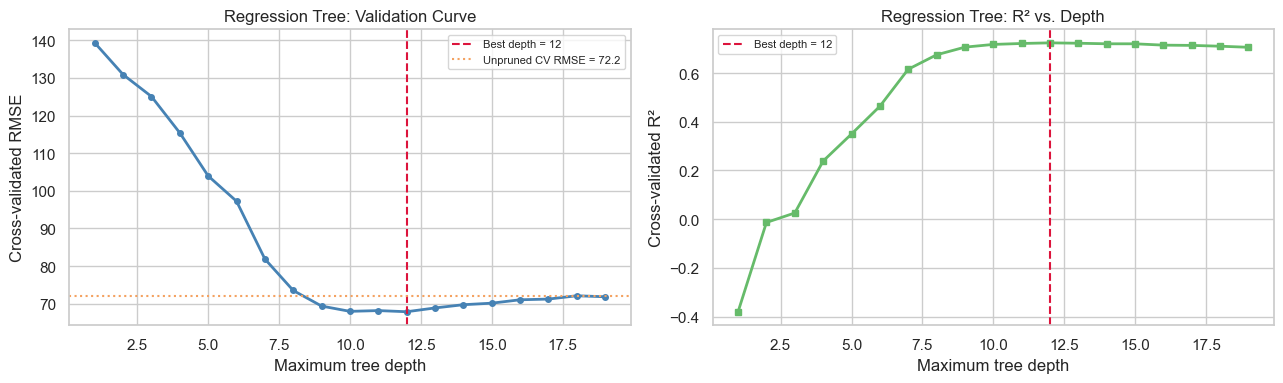

Best max_depth     : 12
Best CV RMSE       : 67.89
Corresponding CV R²: 0.7238
Unpruned CV RMSE   : 72.16


In [6]:
from sklearn.tree import DecisionTreeRegressor, export_text

depth_grid = list(range(1, 20))
cv_rmse_dt, cv_r2_dt = [], []

for d in depth_grid:
    pipe_dt = Pipeline([
        ("clf", DecisionTreeRegressor(
                    max_depth=d, random_state=RANDOM_SEED))
    ])
    rmse_scores = -cross_val_score(
        pipe_dt, X_tr, y_tr, cv=kf,
        scoring="neg_root_mean_squared_error"
    )
    r2_scores = cross_val_score(
        pipe_dt, X_tr, y_tr, cv=kf, scoring="r2"
    )
    cv_rmse_dt.append(rmse_scores.mean())
    cv_r2_dt.append(r2_scores.mean())

cv_rmse_dt = np.array(cv_rmse_dt)
cv_r2_dt   = np.array(cv_r2_dt)
best_depth = depth_grid[np.argmin(cv_rmse_dt)]

# ── Unpruned tree for comparison ──────────────────────────────────────────
pipe_dt_full = Pipeline([
    ("clf", DecisionTreeRegressor(max_depth=None, random_state=RANDOM_SEED))
])
rmse_full = -cross_val_score(
    pipe_dt_full, X_tr, y_tr, cv=kf,
    scoring="neg_root_mean_squared_error"
).mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(depth_grid, cv_rmse_dt, "o-", color="steelblue", lw=2, ms=4)
axes[0].axvline(best_depth, color="crimson", linestyle="--", lw=1.5,
                label=f"Best depth = {best_depth}")
axes[0].axhline(rmse_full, color="#F4A261", linestyle=":", lw=1.5,
                label=f"Unpruned CV RMSE = {rmse_full:.1f}")
axes[0].set_xlabel("Maximum tree depth")
axes[0].set_ylabel("Cross-validated RMSE")
axes[0].set_title("Regression Tree: Validation Curve")
axes[0].legend(fontsize=8)

axes[1].plot(depth_grid, cv_r2_dt, "s-", color="#66BB6A", lw=2, ms=4)
axes[1].axvline(best_depth, color="crimson", linestyle="--", lw=1.5,
                label=f"Best depth = {best_depth}")
axes[1].set_xlabel("Maximum tree depth")
axes[1].set_ylabel("Cross-validated R²")
axes[1].set_title("Regression Tree: R² vs. Depth")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "ch12_dt_valcurve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Best max_depth     : {best_depth}")
print(f"Best CV RMSE       : {cv_rmse_dt.min():.2f}")
print(f"Corresponding CV R²: {cv_r2_dt[best_depth - 1]:.4f}")
print(f"Unpruned CV RMSE   : {rmse_full:.2f}")

### Fitting the Final Regression Tree

In [7]:
pipe_dt_best = Pipeline([
    ("clf", DecisionTreeRegressor(
                max_depth=best_depth, random_state=RANDOM_SEED))
])
pipe_dt_best.fit(X_tr, y_tr)
y_pred_dt = pipe_dt_best.predict(X_te)

dt_metrics = regression_report(y_te, y_pred_dt,
                                label=f"Decision Tree (depth={best_depth})")

Decision Tree (depth=12)        RMSE=  89.03  MAE=  57.70  R²=0.8369


### Visualising the Top Splits

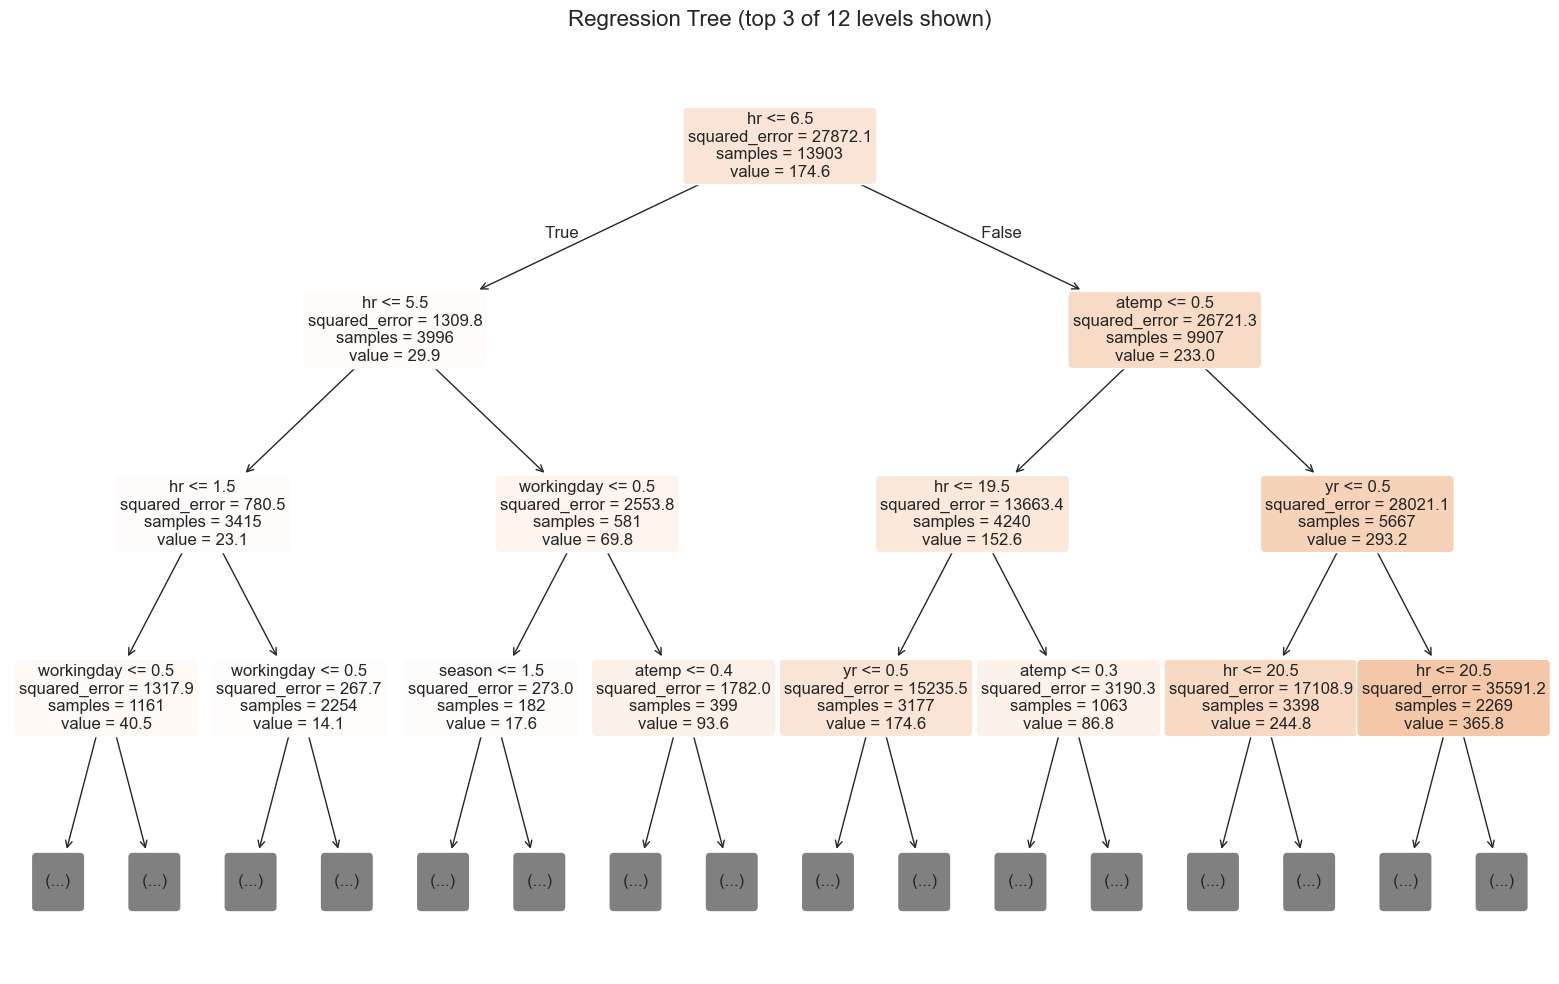

In [47]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(16, 10))
plot_tree(
    pipe_dt_best.named_steps["clf"],
    feature_names=X.columns.tolist(),
    filled=True, rounded=True,
    fontsize=12, ax=ax,
    max_depth=3,
    impurity=True,
    precision=1
)
ax.set_title(f"Regression Tree (top 3 of {best_depth} levels shown)",
             fontsize=16, pad=20)
plt.tight_layout()
plt.savefig(FIGURES / "ch12_dt_tree.png", dpi=150, bbox_inches="tight")
plt.show()

### Feature Importance

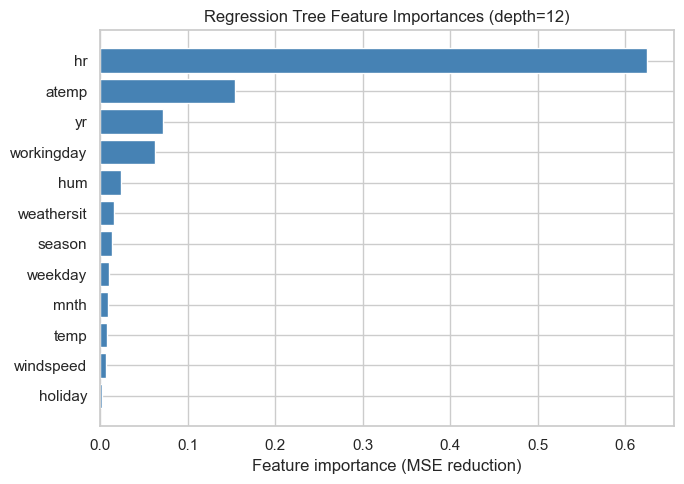

   feature  importance
        hr    0.624751
     atemp    0.154347
        yr    0.071009
workingday    0.062454
       hum    0.023428
weathersit    0.015848
    season    0.013491
   weekday    0.009757
      mnth    0.008985
      temp    0.007582
 windspeed    0.006002
   holiday    0.002345


In [9]:
importances = pipe_dt_best.named_steps["clf"].feature_importances_
imp_df = (pd.DataFrame({"feature": X.columns, "importance": importances})
            .sort_values("importance", ascending=True))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp_df["feature"], imp_df["importance"],
        color="steelblue", edgecolor="white")
ax.set_xlabel("Feature importance (MSE reduction)")
ax.set_title(f"Regression Tree Feature Importances (depth={best_depth})")
plt.tight_layout()
plt.savefig(FIGURES / "ch12_dt_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(imp_df.sort_values("importance", ascending=False).to_string(index=False))

### Residual Analysis

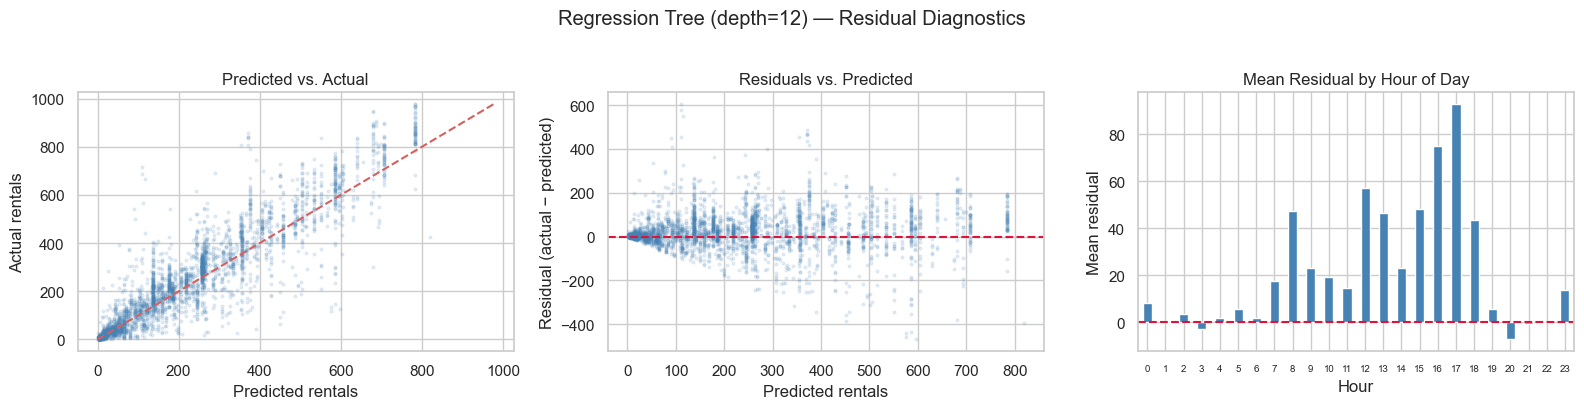

Residual mean : +22.54  (should be ≈ 0)
Residual std  :  86.13


In [10]:
resid_dt = y_te.values - y_pred_dt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel 1: predicted vs. actual
axes[0].scatter(y_pred_dt, y_te.values,
                alpha=0.12, s=4, color="steelblue")
lims = [0, max(y_pred_dt.max(), y_te.max())]
axes[0].plot(lims, lims, "r--", lw=1.5)
axes[0].set_title("Predicted vs. Actual")
axes[0].set_xlabel("Predicted rentals")
axes[0].set_ylabel("Actual rentals")

# Panel 2: residuals vs. predicted
axes[1].scatter(y_pred_dt, resid_dt,
                alpha=0.12, s=4, color="steelblue")
axes[1].axhline(0, color="crimson", lw=1.5, linestyle="--")
axes[1].set_title("Residuals vs. Predicted")
axes[1].set_xlabel("Predicted rentals")
axes[1].set_ylabel("Residual (actual − predicted)")

# Panel 3: residuals by hour of day
resid_by_hr = pd.Series(resid_dt, index=X_te.index)
hr_resid = X_te["hr"].copy()
hr_resid.index = X_te.index
combined = pd.DataFrame({"hr": hr_resid, "resid": resid_by_hr})
combined.groupby("hr")["resid"].mean().plot(
    kind="bar", ax=axes[2], color="steelblue", edgecolor="white"
)
axes[2].axhline(0, color="crimson", lw=1.5, linestyle="--")
axes[2].set_title("Mean Residual by Hour of Day")
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("Mean residual")
axes[2].tick_params(axis='x', rotation=0, labelsize=7)

plt.suptitle(f"Regression Tree (depth={best_depth}) — Residual Diagnostics",
             y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch12_dt_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Residual mean : {resid_dt.mean():+.2f}  (should be ≈ 0)")
print(f"Residual std  :  {resid_dt.std():.2f}")

## Support Vector Regression

### Linear SVR

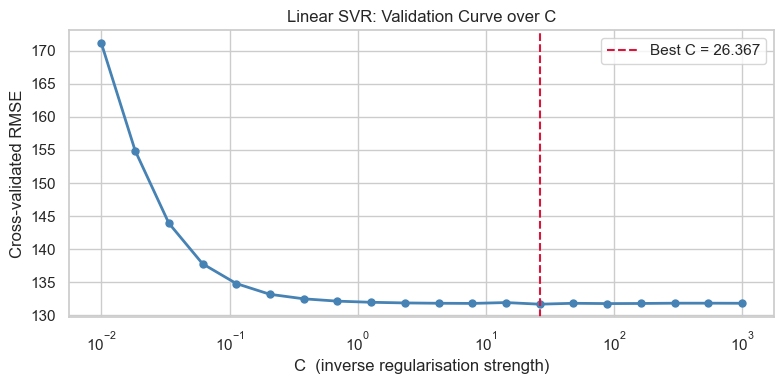

Best C             : 26.3665
Best CV RMSE       : 131.69


In [11]:
from sklearn.svm import LinearSVR, SVR

# ── Linear SVR: tune C ────────────────────────────────────────────────────
C_grid_svr = np.logspace(-2, 3, 20)
cv_rmse_lsvr = []

for C in C_grid_svr:
    pipe_lsvr = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LinearSVR(C=C, max_iter=5000,
                             random_state=RANDOM_SEED))
    ])
    scores = -cross_val_score(
        pipe_lsvr, X_tr, y_tr, cv=kf,
        scoring="neg_root_mean_squared_error"
    )
    cv_rmse_lsvr.append(scores.mean())

cv_rmse_lsvr = np.array(cv_rmse_lsvr)
best_C_lsvr  = C_grid_svr[np.argmin(cv_rmse_lsvr)]

plt.figure(figsize=(8, 4))
plt.semilogx(C_grid_svr, cv_rmse_lsvr, "o-",
             color="steelblue", lw=2, ms=5)
plt.axvline(best_C_lsvr, color="crimson", linestyle="--", lw=1.5,
            label=f"Best C = {best_C_lsvr:.3f}")
plt.xlabel("C  (inverse regularisation strength)")
plt.ylabel("Cross-validated RMSE")
plt.title("Linear SVR: Validation Curve over C")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "ch12_lsvr_valcurve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Best C             : {best_C_lsvr:.4f}")
print(f"Best CV RMSE       : {cv_rmse_lsvr.min():.2f}")

In [12]:
# ── Fit and evaluate Linear SVR ───────────────────────────────────────────
pipe_lsvr_best = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LinearSVR(C=best_C_lsvr, max_iter=5000,
                         random_state=RANDOM_SEED))
])
pipe_lsvr_best.fit(X_tr, y_tr)
y_pred_lsvr = pipe_lsvr_best.predict(X_te)

lsvr_metrics = regression_report(y_te, y_pred_lsvr, label="Linear SVR")

Linear SVR                      RMSE= 198.00  MAE= 135.96  R²=0.1935


### RBF-SVR with Feature Engineering

In [13]:
# ── Add cyclic hour features to both train and test ───────────────────────
def add_cyclic_features(X_df):
    X_out = X_df.copy()
    X_out["hr_sin"] = np.sin(2 * np.pi * X_df["hr"] / 24)
    X_out["hr_cos"] = np.cos(2 * np.pi * X_df["hr"] / 24)
    X_out["mnth_sin"] = np.sin(2 * np.pi * X_df["mnth"] / 12)
    X_out["mnth_cos"] = np.cos(2 * np.pi * X_df["mnth"] / 12)
    return X_out

X_tr_cyc = add_cyclic_features(X_tr)
X_te_cyc = add_cyclic_features(X_te)

print(f"Feature matrix with cyclic encoding: {X_tr_cyc.shape[1]} features "
      f"(was {X_tr.shape[1]})")

Feature matrix with cyclic encoding: 16 features (was 12)


In [14]:
# ── RBF-SVR grid search on a 3,000-row subsample ─────────────────────────
# (RBF-SVR is O(n²)–O(n³); subsampling keeps training time tractable
#  while demonstrating the kernel effect)

from sklearn.model_selection import GridSearchCV

subsample_idx = rng.choice(len(X_tr_cyc), size=3000, replace=False)
X_sub = X_tr_cyc.iloc[subsample_idx]
y_sub = y_tr.iloc[subsample_idx]

param_grid_svr = {
    "clf__C":     [1, 10, 100, 500],
    "clf__gamma": ["scale", 0.01, 0.1],
    "clf__epsilon": [1.0, 5.0, 10.0],
}

gs_svr = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    SVR(kernel="rbf"))
    ]),
    param_grid_svr,
    cv=KFold(n_splits=5, shuffle=False),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1, refit=True
)
gs_svr.fit(X_sub, y_sub)

print("RBF-SVR Grid Search (subsample n=3,000)")
print(f"  Best parameters : {gs_svr.best_params_}")
print(f"  Best CV RMSE    : {-gs_svr.best_score_:.2f}")

RBF-SVR Grid Search (subsample n=3,000)
  Best parameters : {'clf__C': 500, 'clf__epsilon': 10.0, 'clf__gamma': 0.1}
  Best CV RMSE    : 72.97


In [15]:
# ── Refit best RBF-SVR on full training set ───────────────────────────────
best_svr_params = gs_svr.best_params_
pipe_svr_best = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    SVR(kernel="rbf",
                   C=best_svr_params["clf__C"],
                   gamma=best_svr_params["clf__gamma"],
                   epsilon=best_svr_params["clf__epsilon"]))
])
pipe_svr_best.fit(X_tr_cyc, y_tr)
y_pred_svr = pipe_svr_best.predict(X_te_cyc)

svr_metrics = regression_report(y_te, y_pred_svr, label="RBF-SVR (cyclic features)")

RBF-SVR (cyclic features)       RMSE= 126.14  MAE=  78.08  R²=0.6727


### Understanding the ε-Tube and Support Vectors

In [16]:
# ── Fraction of training observations that are support vectors ────────────
n_sv = len(pipe_svr_best.named_steps["clf"].support_vectors_)
frac_sv = n_sv / len(X_tr_cyc)

print(f"Training observations : {len(X_tr_cyc):,}")
print(f"Support vectors       : {n_sv:,}  ({frac_sv:.1%} of training set)")
print(f"\nε (insensitive tube half-width) : "
      f"{best_svr_params['clf__epsilon']:.1f} rentals")
print(f"Predictions within ε of actual  : "
      f"{(np.abs(y_te.values - y_pred_svr) <= best_svr_params['clf__epsilon']).mean():.1%}")

Training observations : 13,903
Support vectors       : 9,878  (71.0% of training set)

ε (insensitive tube half-width) : 10.0 rentals
Predictions within ε of actual  : 16.1%


### SVR Residual Analysis

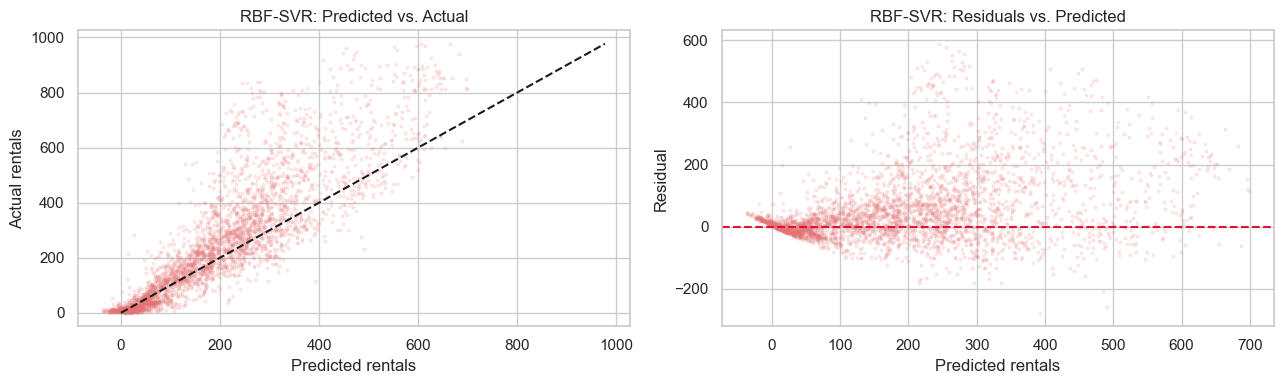

Residual mean : +53.95
Residual std  :  114.02


In [17]:
resid_svr = y_te.values - y_pred_svr

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_pred_svr, y_te.values,
                alpha=0.12, s=4, color="#E57373")
lims = [0, max(y_pred_svr.max(), y_te.max())]
axes[0].plot(lims, lims, "k--", lw=1.5)
axes[0].set_title("RBF-SVR: Predicted vs. Actual")
axes[0].set_xlabel("Predicted rentals")
axes[0].set_ylabel("Actual rentals")

axes[1].scatter(y_pred_svr, resid_svr,
                alpha=0.12, s=4, color="#E57373")
axes[1].axhline(0, color="crimson", lw=1.5, linestyle="--")
axes[1].set_title("RBF-SVR: Residuals vs. Predicted")
axes[1].set_xlabel("Predicted rentals")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.savefig(FIGURES / "ch12_svr_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Residual mean : {resid_svr.mean():+.2f}")
print(f"Residual std  :  {resid_svr.std():.2f}")

## Ensemble Regression: A Preview

### Why Ensemble Methods?

In [18]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ── Random Forest (default n_estimators=100, lightly tuned max_features) ──
pipe_rf = Pipeline([
    ("clf", RandomForestRegressor(
                n_estimators=200,
                max_features="sqrt",
                random_state=RANDOM_SEED,
                n_jobs=-1))
])
pipe_rf.fit(X_tr, y_tr)
y_pred_rf = pipe_rf.predict(X_te)
rf_metrics = regression_report(y_te, y_pred_rf, label="Random Forest")

# ── Gradient Boosting ─────────────────────────────────────────────────────
pipe_gb = Pipeline([
    ("clf", GradientBoostingRegressor(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                random_state=RANDOM_SEED))
])
pipe_gb.fit(X_tr, y_tr)
y_pred_gb = pipe_gb.predict(X_te)
gb_metrics = regression_report(y_te, y_pred_gb, label="Gradient Boosting")

Random Forest                   RMSE= 111.76  MAE=  72.66  R²=0.7431
Gradient Boosting               RMSE=  69.85  MAE=  46.21  R²=0.8996


## Model Comparison and Selection

In [19]:
all_results = []

# Baseline
all_results.append({
    "model": "Baseline (mean)",
    "cv_rmse_mean": np.nan, "cv_rmse_std": np.nan, "cv_r2_mean": np.nan,
    "test_rmse": np.sqrt(mean_squared_error(y_te, y_baseline)),
    "test_mae":  mean_absolute_error(y_te, y_baseline),
    "test_r2":   r2_score(y_te, y_baseline)
})

# Linear SVR (evaluated on original features)
lsvr_cv_rmse = -cross_val_score(
    pipe_lsvr_best, X_tr, y_tr, cv=kf,
    scoring="neg_root_mean_squared_error"
)
lsvr_cv_r2 = cross_val_score(pipe_lsvr_best, X_tr, y_tr, cv=kf, scoring="r2")
all_results.append({
    "model": "Linear SVR",
    "cv_rmse_mean": lsvr_cv_rmse.mean(), "cv_rmse_std": lsvr_cv_rmse.std(),
    "cv_r2_mean":   lsvr_cv_r2.mean(),
    "test_rmse": lsvr_metrics["rmse"],
    "test_mae":  lsvr_metrics["mae"],
    "test_r2":   lsvr_metrics["r2"]
})

# Decision Tree
dt_cv_rmse = -cross_val_score(
    pipe_dt_best, X_tr, y_tr, cv=kf,
    scoring="neg_root_mean_squared_error"
)
dt_cv_r2 = cross_val_score(pipe_dt_best, X_tr, y_tr, cv=kf, scoring="r2")
all_results.append({
    "model": f"Decision Tree (d={best_depth})",
    "cv_rmse_mean": dt_cv_rmse.mean(), "cv_rmse_std": dt_cv_rmse.std(),
    "cv_r2_mean":   dt_cv_r2.mean(),
    "test_rmse": dt_metrics["rmse"],
    "test_mae":  dt_metrics["mae"],
    "test_r2":   dt_metrics["r2"]
})

# RBF-SVR
all_results.append({
    "model": "RBF-SVR (cyclic feats.)",
    "cv_rmse_mean": np.nan, "cv_rmse_std": np.nan, "cv_r2_mean": np.nan,
    "test_rmse": svr_metrics["rmse"],
    "test_mae":  svr_metrics["mae"],
    "test_r2":   svr_metrics["r2"]
})

# Random Forest
all_results.append({
    "model": "Random Forest (preview)",
    "cv_rmse_mean": np.nan, "cv_rmse_std": np.nan, "cv_r2_mean": np.nan,
    "test_rmse": rf_metrics["rmse"],
    "test_mae":  rf_metrics["mae"],
    "test_r2":   rf_metrics["r2"]
})

# Gradient Boosting
all_results.append({
    "model": "Gradient Boosting (preview)",
    "cv_rmse_mean": np.nan, "cv_rmse_std": np.nan, "cv_r2_mean": np.nan,
    "test_rmse": gb_metrics["rmse"],
    "test_mae":  gb_metrics["mae"],
    "test_r2":   gb_metrics["r2"]
})

res_df = (pd.DataFrame(all_results)
            .sort_values("test_r2", ascending=False))

print(res_df[["model", "cv_rmse_mean", "test_rmse", "test_mae", "test_r2"]]
      .to_string(index=False, float_format="{:.2f}".format,
                 na_rep="—"))

                      model  cv_rmse_mean  test_rmse  test_mae  test_r2
Gradient Boosting (preview)             —      69.85     46.21     0.90
       Decision Tree (d=12)         67.89      89.03     57.70     0.84
    Random Forest (preview)             —     111.76     72.66     0.74
    RBF-SVR (cyclic feats.)             —     126.14     78.08     0.67
                 Linear SVR        131.69     198.00    135.96     0.19
            Baseline (mean)             —     232.61    174.98    -0.11


### Comparative Residual Plot

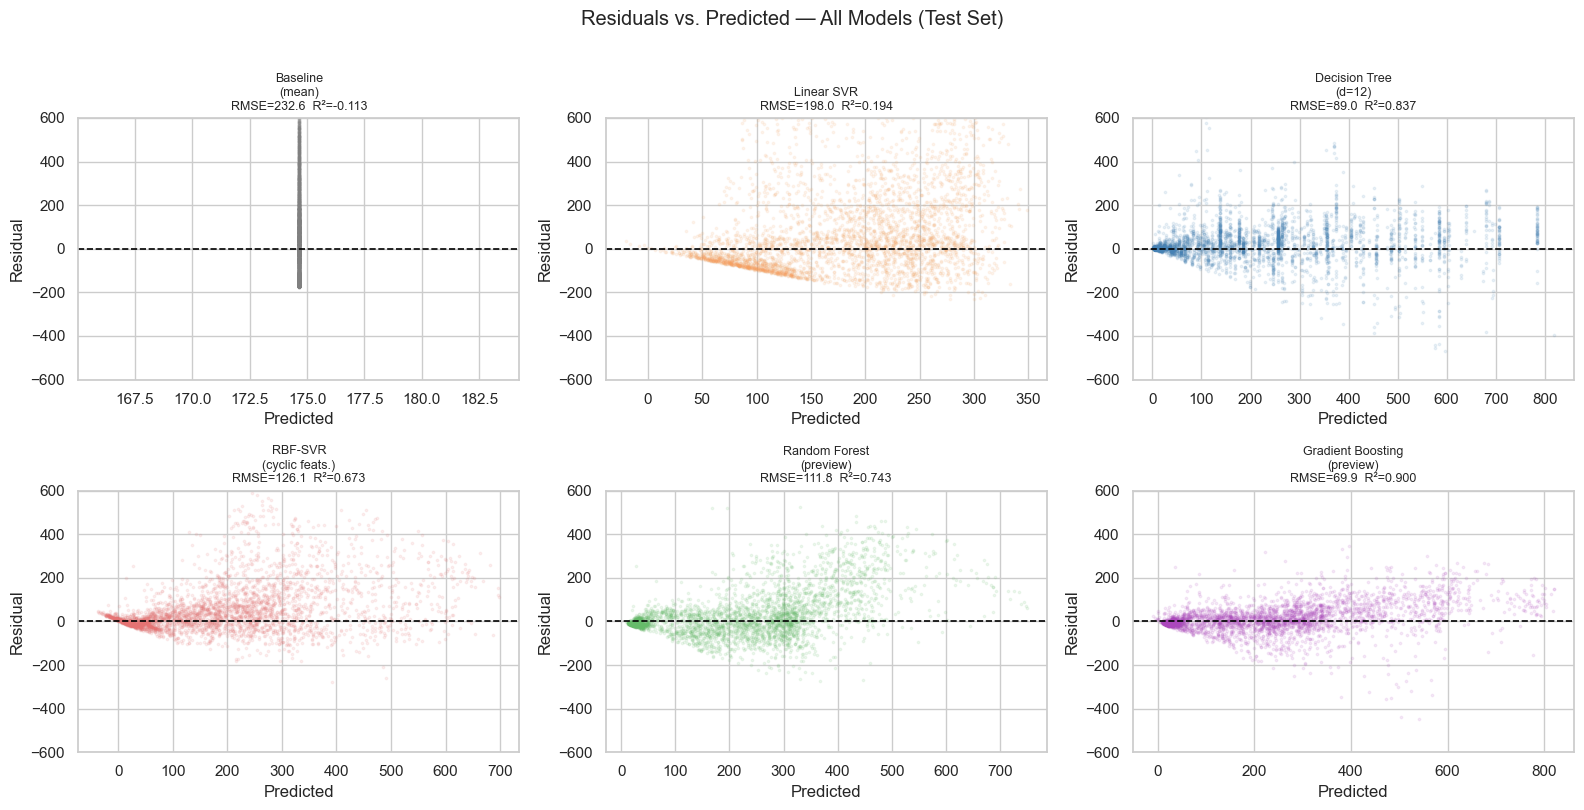

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

model_preds = {
    "Baseline\n(mean)":        y_baseline,
    "Linear SVR":              y_pred_lsvr,
    f"Decision Tree\n(d={best_depth})": y_pred_dt,
    "RBF-SVR\n(cyclic feats.)": y_pred_svr,
    "Random Forest\n(preview)": y_pred_rf,
    "Gradient Boosting\n(preview)": y_pred_gb,
}
colors = ["gray", "#F4A261", "steelblue", "#E57373", "#66BB6A", "#AB47BC"]

for ax, (name, y_pred), color in zip(axes, model_preds.items(), colors):
    r2 = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    ax.scatter(y_pred, y_te.values - y_pred,
               alpha=0.10, s=3, color=color)
    ax.axhline(0, color="black", lw=1.2, linestyle="--")
    ax.set_title(f"{name}\nRMSE={rmse:.1f}  R²={r2:.3f}", fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")
    ax.set_ylim(-600, 600)

plt.suptitle("Residuals vs. Predicted — All Models (Test Set)", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "ch12_all_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

## A Complete Regression Workflow

In [21]:
# ── Systematic evaluation of all models with full CV ─────────────────────
final_results = []

# Decision Tree (best depth)
final_results.append(evaluate_regressor(
    Pipeline([("clf", DecisionTreeRegressor(
                          max_depth=best_depth,
                          random_state=RANDOM_SEED))]),
    X_tr, y_tr, X_te, y_te, kf,
    model_name=f"Decision Tree (d={best_depth})"
))

# Linear SVR (best C)
final_results.append(evaluate_regressor(
    Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LinearSVR(C=best_C_lsvr, max_iter=5000,
                             random_state=RANDOM_SEED))
    ]),
    X_tr, y_tr, X_te, y_te, kf,
    model_name="Linear SVR"
))

out = pd.DataFrame(final_results)
print(out[["model", "cv_rmse_mean", "cv_rmse_std",
           "cv_r2_mean", "test_rmse", "test_r2"]]
      .to_string(index=False, float_format="{:.4f}".format))

               model  cv_rmse_mean  cv_rmse_std  cv_r2_mean  test_rmse  test_r2
Decision Tree (d=12)       67.8948      13.9229      0.7238    89.0343   0.8369
          Linear SVR      131.6941      38.0947      0.1427   198.0041   0.1935
